# Image Classification with Convolutional Neural Networks

**Author:** Albert Kabore, PhD student in AI

## Introduction

This study examines eight-class image classification on the [Natural Images dataset](https://www.kaggle.com/datasets/prasunroy/natural-images), which contains 6,899 labeled photographs of airplanes, cars, cats, dogs, flowers, fruit, motorbikes, and people. The objective is to assess whether batch normalization and dropout improve a compact convolutional neural network (CNN) while keeping the network depth and width fixed.

Two PyTorch CNNs are compared on the same stratified training and validation splits. Learning rate and dropout are then tuned using validation accuracy. The selected model is assessed on a held-out test set using accuracy, macro precision, macro recall, macro F1, and a confusion matrix.

Before running, set `DEFAULT_DATA` in the first code cell to the folder containing the eight class directories.

## 1-4. Data loading, preprocessing, CNN architectures, training loop, and evaluation

The cell below defines: the `Images` dataset (RGB conversion, resize, 0-1 scaling, random flip/brightness augmentation for training only), the `CNN` module (shared conv/pool stack, with batch normalization and dropout toggled by `regularized`), the training loop (`train_variant`, using cross-entropy loss and the Adam optimizer), and evaluation (`evaluate`, plus precision/recall/F1/confusion-matrix reporting).

In [1]:
import argparse
import json
import random
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageEnhance, ImageOps
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset


CLASSES = ["airplane", "car", "cat", "dog", "flower", "fruit", "motorbike", "person"]
DEFAULT_DATA = Path(r"C:\Users\alber\OneDrive\Documents\archive\natural_images")
DEFAULT_DROPOUT = 0.3


class Images(Dataset):
    def __init__(self, samples, size, augment=False):
        self.samples, self.size, self.augment = samples, size, augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        path, label = self.samples[index]
        with Image.open(path) as source:
            image = source.convert("RGB").resize((self.size, self.size), Image.Resampling.BILINEAR)
        if self.augment:
            if random.random() < 0.5:
                image = ImageOps.mirror(image)
            image = ImageEnhance.Brightness(image).enhance(random.uniform(0.85, 1.15))
        array = np.asarray(image, dtype=np.float32).copy() / 255.0
        return torch.from_numpy(array).permute(2, 0, 1), label


class CNN(nn.Module):
    def __init__(self, regularized=False, dropout=DEFAULT_DROPOUT):
        super().__init__()
        layers = []
        channels = 3
        for width in (16, 32, 64):
            layers += [nn.Conv2d(channels, width, 3, padding=1)]
            if regularized:
                layers += [nn.BatchNorm2d(width)]
            layers += [nn.ReLU(), nn.MaxPool2d(2)]
            channels = width
        self.features = nn.Sequential(*layers, nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.classifier = nn.Sequential(nn.Dropout(dropout) if regularized else nn.Identity(), nn.Linear(64, len(CLASSES)))

    def forward(self, x):
        return self.classifier(self.features(x))


def collect(root):
    samples = []
    for label, name in enumerate(CLASSES):
        directory = root / name
        if not directory.is_dir():
            raise FileNotFoundError(f"Missing class directory: {directory}")
        samples.extend((p, label) for p in sorted(directory.iterdir()) if p.suffix.lower() in {".jpg", ".jpeg", ".png"})
    if not samples:
        raise ValueError(f"No images found in {root}")
    return samples


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, targets, predictions = 0.0, [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            total_loss += criterion(logits, labels).item() * len(labels)
            targets.extend(labels.cpu().tolist())
            predictions.extend(logits.argmax(1).cpu().tolist())
    return total_loss / len(loader.dataset), accuracy_score(targets, predictions), targets, predictions


def train_variant(name, regularized, loaders, epochs, lr, device, dropout=DEFAULT_DROPOUT):
    torch.manual_seed(42)
    model = CNN(regularized, dropout=dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {key: [] for key in ("train_loss", "train_accuracy", "val_loss", "val_accuracy")}
    best_accuracy, best_state = -1, None
    for epoch in range(epochs):
        model.train()
        loss_sum, correct = 0.0, 0
        for images, labels in loaders[0]:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
        val_loss, val_accuracy, _, _ = evaluate(model, loaders[1], criterion, device)
        for key, value in zip(history, (loss_sum / len(loaders[0].dataset), correct / len(loaders[0].dataset), val_loss, val_accuracy)):
            history[key].append(float(value))
        if val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"{name} epoch {epoch + 1}/{epochs}: train acc={history['train_accuracy'][-1]:.3f}, val acc={val_accuracy:.3f}", flush=True)
    model.load_state_dict(best_state)
    return model, history, best_accuracy


def plot_results(history, matrix, output):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for name, values in history.items():
        axes[0].plot(range(1, len(values["train_loss"]) + 1), values["train_loss"], label=f"{name} train")
        axes[0].plot(range(1, len(values["val_loss"]) + 1), values["val_loss"], linestyle="--", label=f"{name} val")
    axes[0].set(xlabel="Epoch", ylabel="Cross entropy loss", title="Loss")
    axes[0].legend(fontsize=8)
    for name, values in history.items():
        axes[1].plot(range(1, len(values["train_accuracy"]) + 1), values["train_accuracy"], label=f"{name} train")
        axes[1].plot(range(1, len(values["val_accuracy"]) + 1), values["val_accuracy"], linestyle="--", label=f"{name} val")
    axes[1].set(xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1), title="Accuracy")
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(output / "training_curves.png", dpi=160)
    plt.close(fig)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(range(8), CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(8), CLASSES)
    ax.set(xlabel="Predicted", ylabel="Actual", title="Test confusion matrix")
    for i in range(8):
        for j in range(8):
            ax.text(j, i, str(matrix[i][j]), ha="center", va="center", color="white" if matrix[i][j] > matrix.max() / 2 else "black", fontsize=8)
    fig.tight_layout()
    fig.savefig(output / "confusion_matrix.png", dpi=160)
    plt.close(fig)


def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--data", type=Path, default=DEFAULT_DATA)
    parser.add_argument("--output", type=Path, default=Path("results"))
    parser.add_argument("--epochs", type=int, default=4)
    parser.add_argument("--batch-size", type=int, default=64)
    parser.add_argument("--image-size", type=int, default=48)
    parser.add_argument("--learning-rate", type=float, default=0.001)
    args = parser.parse_args()
    if args.epochs < 1 or args.image_size < 8:
        parser.error("epochs must be positive and image-size at least 8")
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    torch.set_num_threads(min(4, torch.get_num_threads()))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    samples = collect(args.data)
    labels = [label for _, label in samples]
    train_val, test = train_test_split(samples, test_size=0.15, stratify=labels, random_state=42)
    train, val = train_test_split(train_val, test_size=0.15 / 0.85, stratify=[label for _, label in train_val], random_state=42)
    args.output.mkdir(parents=True, exist_ok=True)
    loaders = {}
    for name, subset in (("train", train), ("val", val), ("test", test)):
        loaders[name] = DataLoader(Images(subset, args.image_size, augment=name == "train"), batch_size=args.batch_size, shuffle=name == "train", num_workers=0)
    print(f"Device={device}; split: train={len(train)}, val={len(val)}, test={len(test)}", flush=True)
    histories, scores = {}, {}
    start = time.time()
    for name, regularized in (("baseline", False), ("regularized", True)):
        model, history, val_accuracy = train_variant(name, regularized, (loaders["train"], loaders["val"]), args.epochs, args.learning_rate, device)
        histories[name] = history
        scores[name] = val_accuracy
        torch.save(model.state_dict(), args.output / f"{name}.pt")
    winner = max(scores, key=scores.get)
    model = CNN(winner == "regularized").to(device)
    model.load_state_dict(torch.load(args.output / f"{winner}.pt", map_location=device, weights_only=True))
    test_loss, test_accuracy, actual, predicted = evaluate(model, loaders["test"], nn.CrossEntropyLoss(), device)
    precision, recall, f1, _ = precision_recall_fscore_support(actual, predicted, average="macro", zero_division=0)
    matrix = confusion_matrix(actual, predicted, labels=list(range(8)))
    report = classification_report(actual, predicted, target_names=CLASSES, output_dict=True, zero_division=0)
    result = {"dataset": str(args.data), "class_counts": {name: labels.count(i) for i, name in enumerate(CLASSES)}, "split": {"train": len(train), "validation": len(val), "test": len(test)}, "seed": 42, "device": str(device), "epochs_per_variant": args.epochs, "image_size": args.image_size, "batch_size": args.batch_size, "learning_rate": args.learning_rate, "dropout": DEFAULT_DROPOUT, "validation_accuracy": scores, "selected_model": winner, "test": {"loss": test_loss, "accuracy": test_accuracy, "macro_precision": precision, "macro_recall": recall, "macro_f1": f1, "classification_report": report, "confusion_matrix": matrix.tolist()}, "history": histories, "elapsed_seconds": time.time() - start}
    (args.output / "metrics.json").write_text(json.dumps(result, indent=2), encoding="utf-8")
    plot_results(histories, matrix, args.output)
    print(f"Selected {winner}; test accuracy={test_accuracy:.4f}; macro precision={precision:.4f}; macro recall={recall:.4f}", flush=True)




### Run the architecture comparison

Trains the baseline and regularized CNNs, selects the one with the higher validation accuracy, and evaluates it once on the held-out test set. The default data path points to the local dataset; set `--data` below if the class folders are elsewhere.

In [2]:
import sys
sys.argv = ["train.py", "--epochs", "3"]
main()

Device=cpu; split: train=4829, val=1035, test=1035
baseline epoch 1/3: train acc=0.242, val acc=0.402
baseline epoch 2/3: train acc=0.433, val acc=0.531
baseline epoch 3/3: train acc=0.539, val acc=0.547
regularized epoch 1/3: train acc=0.551, val acc=0.636
regularized epoch 2/3: train acc=0.694, val acc=0.718
regularized epoch 3/3: train acc=0.729, val acc=0.756
Selected regularized; test accuracy=0.7459; macro precision=0.7370; macro recall=0.7273


### Dataset inspection

The categories have unequal sample counts (702 dogs to 1,000 fruit images). The stratified split preserves these proportions. The images below give one example per category.

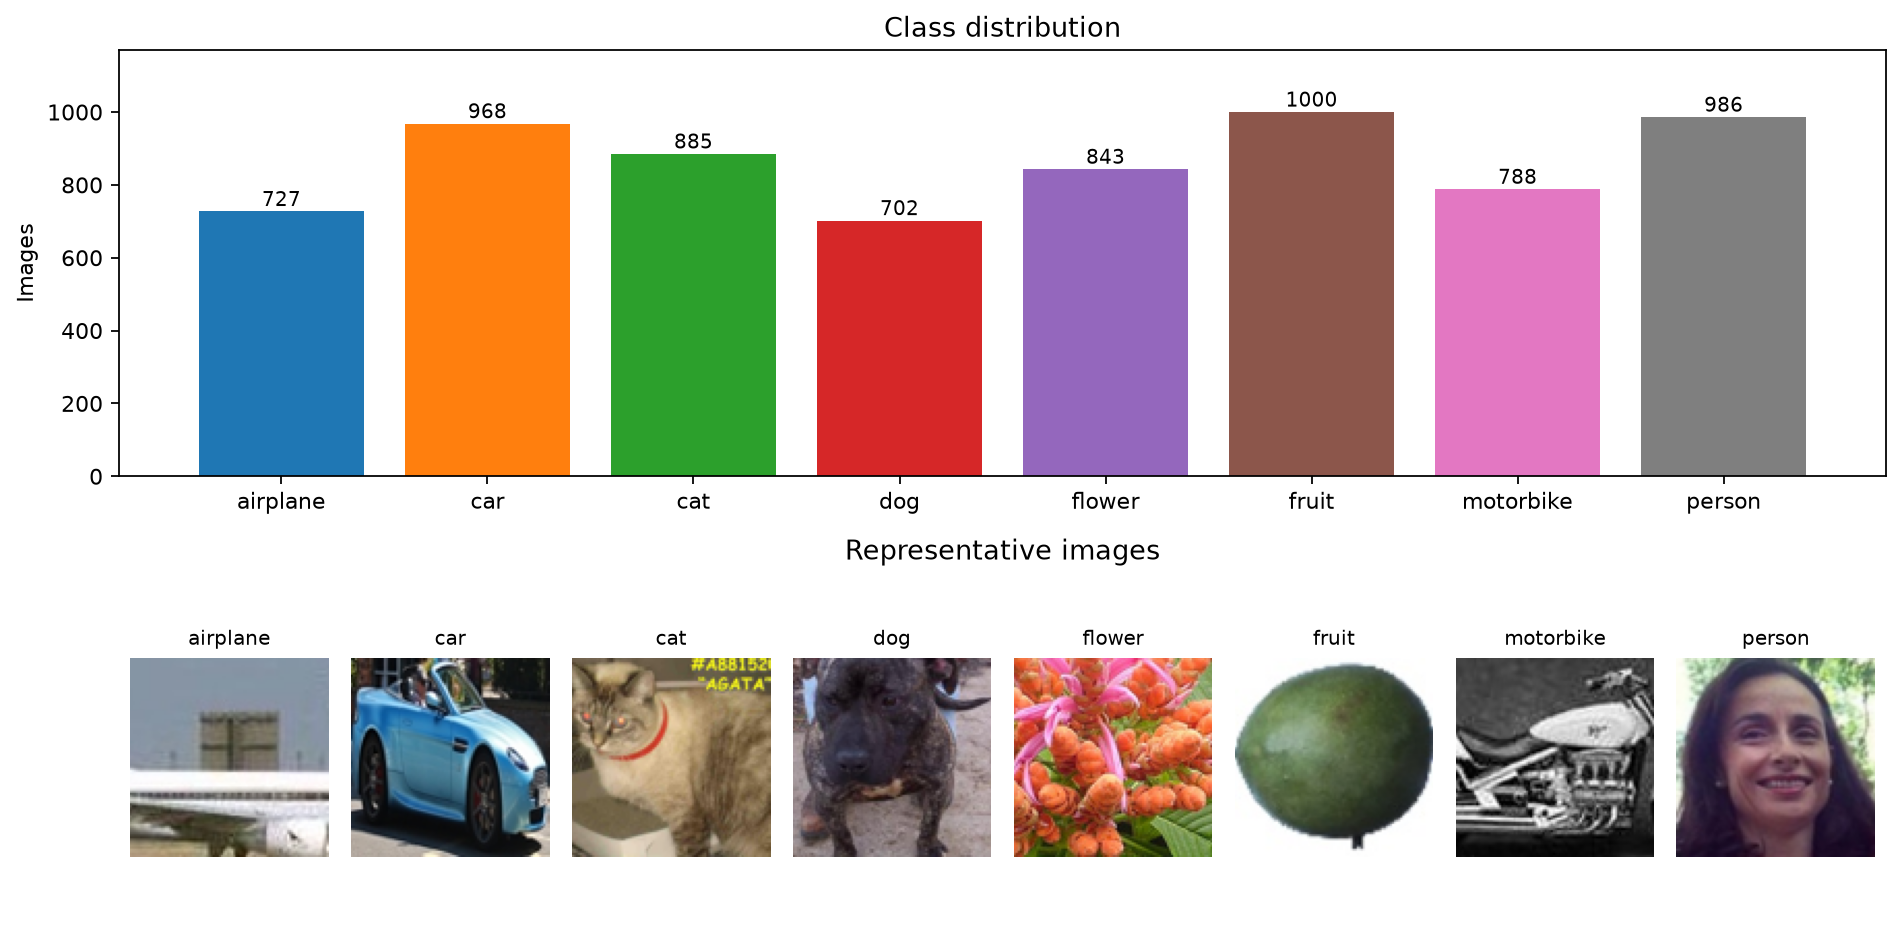

In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from IPython.display import display, Image as NotebookImage
metrics = json.loads(Path("results/metrics.json").read_text())
classes = list(metrics["class_counts"])
counts = [metrics["class_counts"][c] for c in classes]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={"height_ratios": [1.2, 1]})
axes[0].bar(classes, counts, color=plt.cm.tab10.colors[:8])
axes[0].set(title="Class distribution", ylabel="Images", ylim=(0, max(counts) * 1.17))
for i, count in enumerate(counts):
    axes[0].text(i, count + 15, str(count), ha="center", fontsize=9)
for i, name in enumerate(classes):
    files = sorted(x for x in (Path(metrics["dataset"]) / name).iterdir() if x.suffix.lower() in {".jpg", ".jpeg", ".png"})
    with Image.open(files[len(files) // 2]) as image:
        thumb = ImageOps.fit(image.convert("RGB"), (96, 96))
    inset = axes[1].inset_axes(((i + 0.05) / 8, 0.08, 0.9 / 8, 0.8))
    inset.imshow(thumb)
    inset.set_title(name, fontsize=9)
    inset.axis("off")
axes[1].axis("off")
axes[1].set_title("Representative images")
fig.tight_layout()
fig.savefig("results/dataset_overview.png", dpi=160, bbox_inches="tight")
plt.close(fig)
display(NotebookImage(filename="results/dataset_overview.png"))

## 5. Hyperparameter tuning/experiments

Starting from the architecture that won the comparison above, this sweeps the learning rate, then the dropout rate, at three epochs per configuration, and promotes the tuned configuration to the final model only if it beats the original on validation accuracy.

In [3]:
import json
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from torch import nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import train_test_split


LEARNING_RATES = [0.0003, 0.001, 0.003]
DROPOUT_RATES = [0.1, DEFAULT_DROPOUT, 0.5]
EPOCHS = 3
BATCH_SIZE = 64
IMAGE_SIZE = 48


def main():
    output = Path("results")
    baseline_metrics = json.loads((output / "metrics.json").read_text(encoding="utf-8"))
    prior_val_accuracy = baseline_metrics["validation_accuracy"][baseline_metrics["selected_model"]]

    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    samples = collect(DEFAULT_DATA)
    labels = [label for _, label in samples]
    train_val, test = train_test_split(samples, test_size=0.15, stratify=labels, random_state=42)
    train, val = train_test_split(train_val, test_size=0.15 / 0.85, stratify=[label for _, label in train_val], random_state=42)
    train_loader = DataLoader(Images(train, IMAGE_SIZE, augment=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(Images(val, IMAGE_SIZE), batch_size=BATCH_SIZE, num_workers=0)
    test_loader = DataLoader(Images(test, IMAGE_SIZE), batch_size=BATCH_SIZE, num_workers=0)
    print(f"Device={device}; train={len(train)}, val={len(val)}, test={len(test)}", flush=True)

    start = time.time()

    lr_results = {}
    for lr in LEARNING_RATES:
        _, history, best_val = train_variant(f"lr={lr}", True, (train_loader, val_loader), EPOCHS, lr, device)
        lr_results[lr] = {"best_val_accuracy": best_val, "history": history}
        print(f"lr={lr}: best val accuracy={best_val:.4f}", flush=True)
    best_lr = max(lr_results, key=lambda k: lr_results[k]["best_val_accuracy"])

    dropout_results = {}
    best_model, best_history, best_dropout_val = None, None, -1
    for dropout in DROPOUT_RATES:
        model, history, best_val = train_variant(f"dropout={dropout}", True, (train_loader, val_loader), EPOCHS, best_lr, device, dropout=dropout)
        dropout_results[dropout] = {"best_val_accuracy": best_val, "history": history}
        print(f"lr={best_lr}, dropout={dropout}: best val accuracy={best_val:.4f}", flush=True)
        if best_val > best_dropout_val:
            best_dropout_val, best_model, best_history = best_val, model, history

    best_dropout = max(dropout_results, key=lambda k: dropout_results[k]["best_val_accuracy"])
    tuned_val_accuracy = dropout_results[best_dropout]["best_val_accuracy"]

    result = {
        "learning_rates_tried": LEARNING_RATES,
        "dropout_rates_tried": DROPOUT_RATES,
        "epochs_per_run": EPOCHS,
        "learning_rate_sweep": {str(k): v["best_val_accuracy"] for k, v in lr_results.items()},
        "dropout_sweep_at_best_lr": {str(k): v["best_val_accuracy"] for k, v in dropout_results.items()},
        "best_learning_rate": best_lr,
        "best_dropout": best_dropout,
        "tuned_validation_accuracy": tuned_val_accuracy,
        "prior_validation_accuracy": prior_val_accuracy,
        "improved_over_prior": tuned_val_accuracy > prior_val_accuracy,
    }

    if tuned_val_accuracy > prior_val_accuracy:
        test_loss, test_accuracy, actual, predicted = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)
        precision, recall, f1, _ = precision_recall_fscore_support(actual, predicted, average="macro", zero_division=0)
        matrix = confusion_matrix(actual, predicted, labels=list(range(len(CLASSES))))
        report = classification_report(actual, predicted, target_names=CLASSES, output_dict=True, zero_division=0)
        result["tuned_test"] = {
            "loss": test_loss, "accuracy": test_accuracy, "macro_precision": precision,
            "macro_recall": recall, "macro_f1": f1, "classification_report": report,
            "confusion_matrix": matrix.tolist(),
        }
        torch.save(best_model.state_dict(), output / "tuned.pt")
        print(f"Tuned model improves on prior best ({tuned_val_accuracy:.4f} > {prior_val_accuracy:.4f}); test accuracy={test_accuracy:.4f}", flush=True)
    else:
        print(f"Tuned model does not exceed prior best val accuracy ({tuned_val_accuracy:.4f} <= {prior_val_accuracy:.4f}); keeping original selected model.", flush=True)

    result["elapsed_seconds"] = time.time() - start
    (output / "tuning.json").write_text(json.dumps(result, indent=2), encoding="utf-8")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].bar([str(lr) for lr in LEARNING_RATES], [lr_results[lr]["best_val_accuracy"] for lr in LEARNING_RATES])
    axes[0].set(xlabel="Learning rate", ylabel="Best validation accuracy", title=f"Learning rate sweep ({EPOCHS} epochs)")
    axes[1].bar([str(d) for d in DROPOUT_RATES], [dropout_results[d]["best_val_accuracy"] for d in DROPOUT_RATES])
    axes[1].set(xlabel="Dropout rate", ylabel="Best validation accuracy", title=f"Dropout sweep at lr={best_lr}")
    fig.tight_layout()
    fig.savefig(output / "tuning_curves.png", dpi=160)
    plt.close(fig)
    print(f"Saved results/tuning.json and results/tuning_curves.png ({result['elapsed_seconds']:.1f}s)", flush=True)




In [4]:
main()

Device=cpu; train=4829, val=1035, test=1035
lr=0.0003 epoch 1/3: train acc=0.429, val acc=0.612
lr=0.0003 epoch 2/3: train acc=0.612, val acc=0.682
lr=0.0003 epoch 3/3: train acc=0.653, val acc=0.695
lr=0.0003: best val accuracy=0.6947
lr=0.001 epoch 1/3: train acc=0.551, val acc=0.636
lr=0.001 epoch 2/3: train acc=0.694, val acc=0.718
lr=0.001 epoch 3/3: train acc=0.729, val acc=0.756
lr=0.001: best val accuracy=0.7556
lr=0.003 epoch 1/3: train acc=0.609, val acc=0.473
lr=0.003 epoch 2/3: train acc=0.717, val acc=0.515
lr=0.003 epoch 3/3: train acc=0.746, val acc=0.690
lr=0.003: best val accuracy=0.6899
dropout=0.1 epoch 1/3: train acc=0.583, val acc=0.621
dropout=0.1 epoch 2/3: train acc=0.725, val acc=0.722
dropout=0.1 epoch 3/3: train acc=0.766, val acc=0.706
lr=0.001, dropout=0.1: best val accuracy=0.7217
dropout=0.3 epoch 1/3: train acc=0.547, val acc=0.641
dropout=0.3 epoch 2/3: train acc=0.695, val acc=0.718
dropout=0.3 epoch 3/3: train acc=0.736, val acc=0.743
lr=0.001, dropou

### Performance across classes and experiments

The regularized CNN has higher validation accuracy than the baseline. On the held-out set, dog recall is 0.171, while person recall is 0.973 and fruit recall is 1.000; these differences are obscured by overall accuracy. The learning-rate and dropout sweeps are separate validation experiments. The test metrics use held-out images.

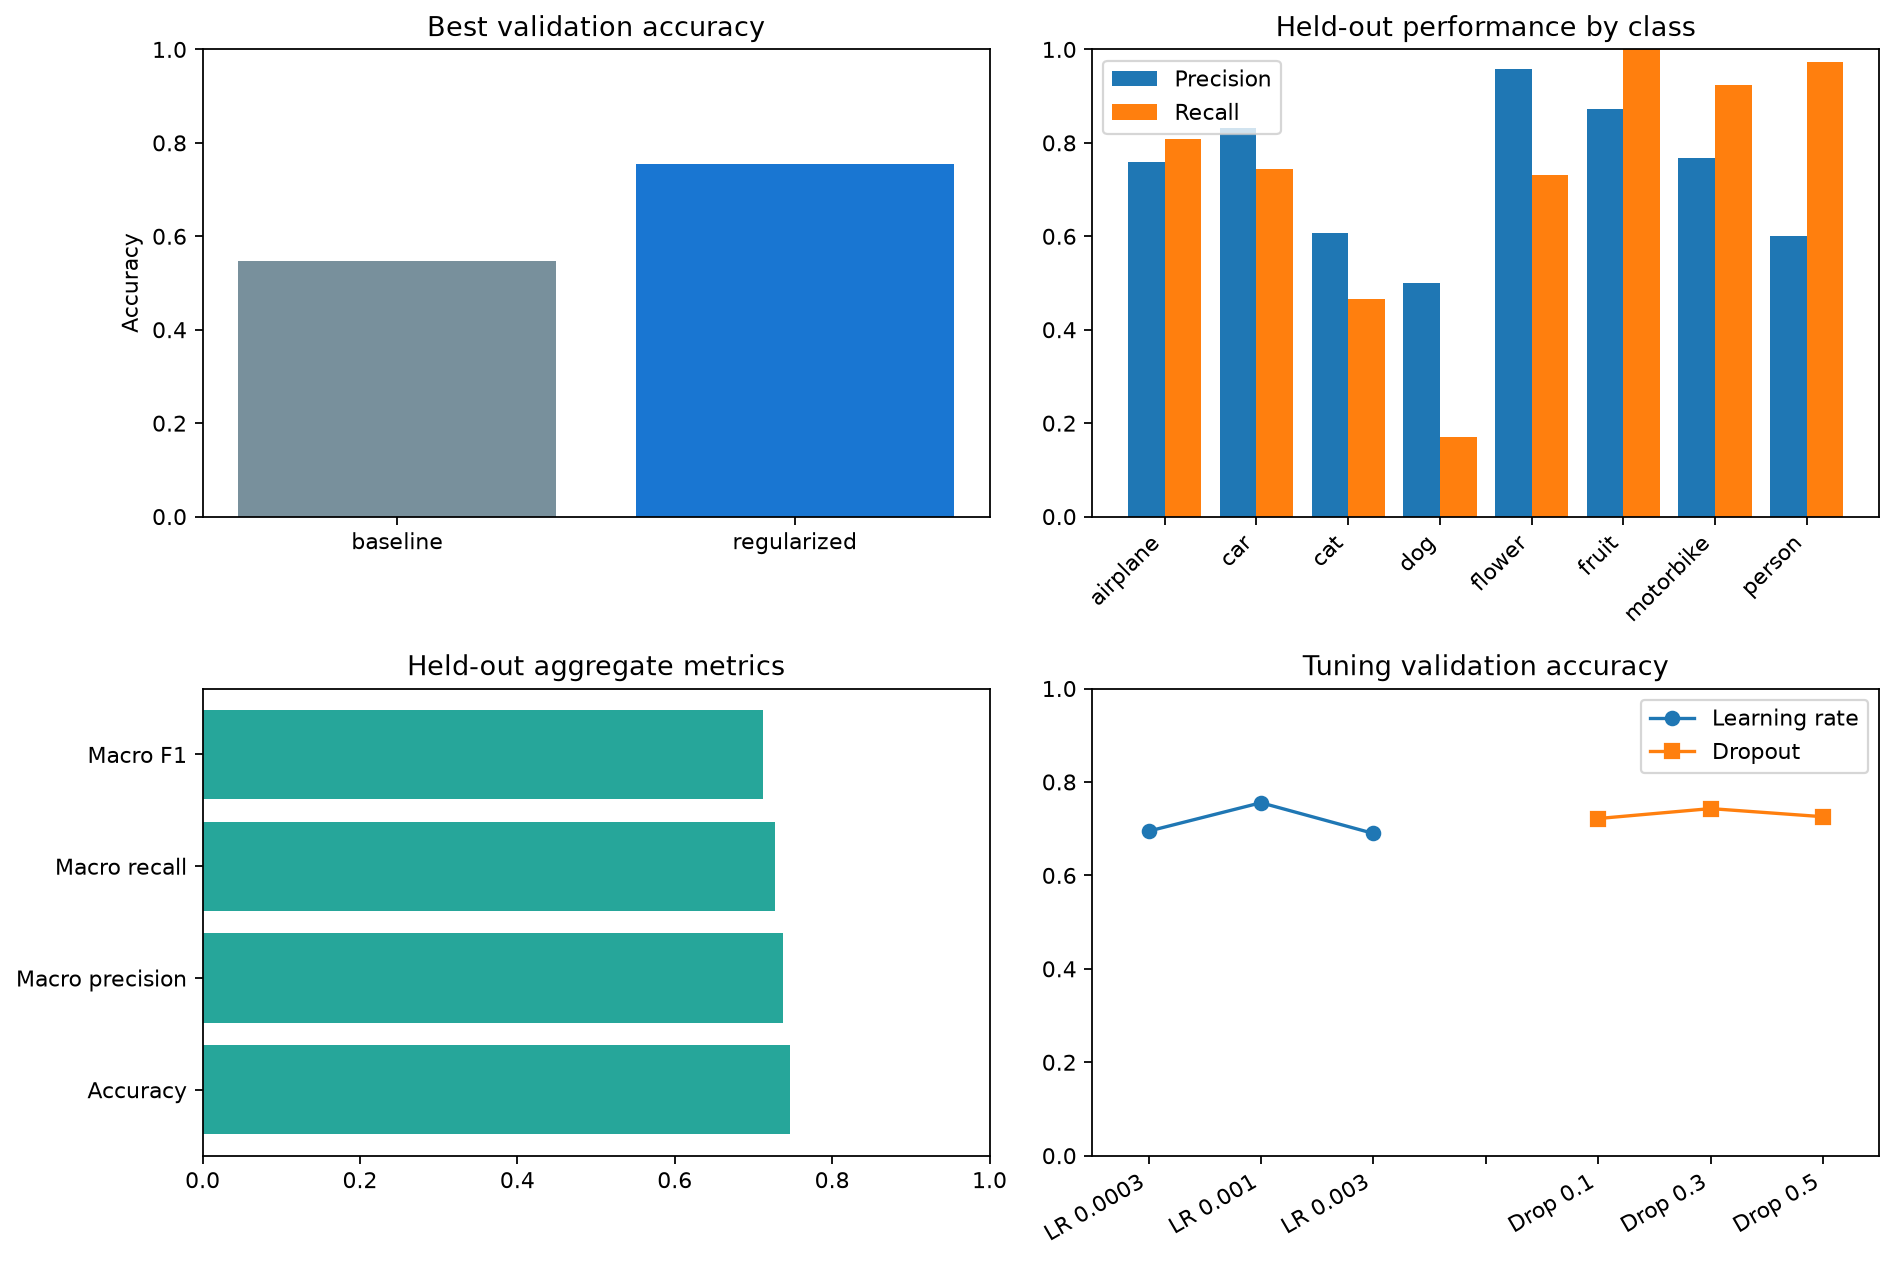

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image as NotebookImage
metrics = json.loads(Path("results/metrics.json").read_text())
tuning = json.loads(Path("results/tuning.json").read_text())
classes = list(metrics["class_counts"])
report = metrics["test"]["classification_report"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
names = list(metrics["validation_accuracy"])
vals = [metrics["validation_accuracy"][x] for x in names]
axes[0, 0].bar(names, vals, color=["#78909c", "#1976d2"])
axes[0, 0].set(title="Best validation accuracy", ylabel="Accuracy", ylim=(0, 1))
x = np.arange(len(classes))
axes[0, 1].bar(x - .2, [report[c]["precision"] for c in classes], .4, label="Precision")
axes[0, 1].bar(x + .2, [report[c]["recall"] for c in classes], .4, label="Recall")
axes[0, 1].set_xticks(x, classes, rotation=45, ha="right")
axes[0, 1].set(title="Held-out performance by class", ylim=(0, 1))
axes[0, 1].legend()
test = metrics["test"]
labels = ["Accuracy", "Macro precision", "Macro recall", "Macro F1"]
values = [test["accuracy"], test["macro_precision"], test["macro_recall"], test["macro_f1"]]
axes[1, 0].barh(labels, values, color="#26a69a")
axes[1, 0].set(title="Held-out aggregate metrics", xlim=(0, 1))
lrs, drops = tuning["learning_rates_tried"], tuning["dropout_rates_tried"]
axes[1, 1].plot(range(3), [tuning["learning_rate_sweep"][str(v)] for v in lrs], "o-", label="Learning rate")
axes[1, 1].plot(range(4, 7), [tuning["dropout_sweep_at_best_lr"][str(v)] for v in drops], "s-", label="Dropout")
axes[1, 1].set_xticks(range(7), [*[f"LR {v}" for v in lrs], "", *[f"Drop {v}" for v in drops]], rotation=30, ha="right")
axes[1, 1].set_xlim(-0.5, 6.5)
axes[1, 1].set(title="Tuning validation accuracy", ylim=(0, 1))
axes[1, 1].legend()
fig.tight_layout()
fig.savefig("results/performance_dashboard.png", dpi=160, bbox_inches="tight")
plt.close(fig)
display(NotebookImage(filename="results/performance_dashboard.png"))

## 6. Project report

In [5]:
"""Narrative text and figures shared by the .docx report and the notebook, built from measured results."""
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


def draw_architecture_diagram(path, dropout=0.3):
    labels = [
        "Input\n48x48x3",
        "Conv 3x3, 16\n+BN if regularized\nReLU, MaxPool 2x2",
        "Conv 3x3, 32\n+BN if regularized\nReLU, MaxPool 2x2",
        "Conv 3x3, 64\n+BN if regularized\nReLU, MaxPool 2x2",
        "Global\nAvg Pool",
        f"Dropout {dropout}\nif regularized",
        "Linear\n-> 8 classes",
    ]
    box_w, box_h, gap = 1.9, 1.0, 0.45
    fig_w = len(labels) * box_w + (len(labels) - 1) * gap + 0.6
    fig, ax = plt.subplots(figsize=(fig_w, 2.2))
    ax.axis("off")
    ax.set_xlim(0, fig_w)
    ax.set_ylim(0, box_h + 0.6)
    x, rights = 0.3, []
    for label in labels:
        ax.add_patch(FancyBboxPatch((x, 0.3), box_w, box_h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                     linewidth=1.3, edgecolor="#2b6cb0", facecolor="#ebf4ff"))
        ax.text(x + box_w / 2, 0.3 + box_h / 2, label, ha="center", va="center", fontsize=8.5)
        rights.append(x + box_w)
        x += box_w + gap
    for right in rights[:-1]:
        ax.annotate("", xy=(right + gap, 0.3 + box_h / 2), xytext=(right, 0.3 + box_h / 2),
                     arrowprops=dict(arrowstyle="->", color="#2b6cb0", lw=1.3))
    fig.tight_layout()
    fig.savefig(path, dpi=160)
    plt.close(fig)


def introduction(metrics):
    total = sum(metrics["class_counts"].values())
    return (f"This project studies eight-class image classification with PyTorch CNNs. "
            f"The Natural Images dataset contains {total:,} labeled photographs of airplanes, "
            "cars, cats, dogs, flowers, fruit, motorbikes, and people. The question is whether "
            "adding batch normalization and dropout to a compact CNN improves classification "
            "when both variants use the same data split, depth, width, optimizer, and training "
            "schedule. Model selection uses validation accuracy; accuracy and class-sensitive "
            "metrics on held-out images describe the final model's performance.")


def preprocessing(metrics):
    split = metrics["split"]
    return (f"Images were divided with stratified random sampling (seed {metrics['seed']}) into "
            f"{split['train']} training, {split['validation']} validation, and {split['test']} "
            "test examples (70/15/15). Validation accuracy selected the architecture; its "
            "checkpoint was then evaluated on the test set before the later tuning sweep. "
            f"All images were converted to RGB, resized to {metrics['image_size']} x "
            f"{metrics['image_size']} pixels, and scaled from 0-255 to 0-1. Training images alone "
            "received random horizontal flips and brightness changes (factor 0.85-1.15).")


def architecture(metrics):
    dropout = metrics.get("dropout", 0.3)
    return ("Both networks use three 3x3 convolution blocks with 16, 32, and 64 output channels. "
            "Each block has ReLU and 2x2 max pooling. Global average pooling maps each channel to "
            "one value, followed by a linear eight-class classifier. The regularized variant adds "
            f"batch normalization after every convolution and {dropout:.0%} dropout before the "
            "classifier. The baseline omits both. This comparison tests the combined design "
            "change while keeping network width and depth fixed.")


def training_setup(metrics):
    return (f"Both variants were trained for {metrics['epochs_per_variant']} epochs using cross "
            f"entropy loss, Adam with learning rate {metrics['learning_rate']}, and batch size "
            f"{metrics['batch_size']}. The checkpoint with the highest validation accuracy for "
            "each variant was saved; the variant with the higher validation accuracy was "
            f"selected. Ties favor the baseline. Training ran on {metrics['device']}. No test "
            "labels were used for optimization. These starting hyperparameters were then tuned "
            "by a grid search over learning rate and dropout rate, reported and justified in the "
            "Discussion section.")


def results_summary_lines(metrics, test):
    lines = [f"{name.capitalize()} best validation accuracy: {score:.3%}" for name, score in metrics["validation_accuracy"].items()]
    lines.append(
        f"Selected model: {metrics['selected_model']}. Test accuracy: {test['accuracy']:.3%}; "
        f"macro precision: {test['macro_precision']:.3f}; macro recall: {test['macro_recall']:.3f}; "
        f"macro F1: {test['macro_f1']:.3f}; test cross entropy: {test['loss']:.3f}."
    )
    return lines


def tuning_intro(tuning):
    return (f"Starting from the winning architecture, learning rate and dropout were tuned by a "
            f"two-stage grid search, each run for {tuning['epochs_per_run']} epochs and scored by "
            "validation accuracy. First, the learning rate was swept with dropout fixed at its "
            "original value; then dropout was swept at the best learning rate found. This keeps "
            "the search small (six training runs, including one repeated configuration) while "
            "probing both an optimization and a regularization hyperparameter.")


def tuning_outcome(metrics, tuning, final):
    if tuning["improved_over_prior"]:
        return (f"The tuned configuration (learning rate {tuning['best_learning_rate']}, dropout "
                f"{tuning['best_dropout']}) reached {tuning['tuned_validation_accuracy']:.3%} "
                f"validation accuracy, exceeding the original {tuning['prior_validation_accuracy']:.3%}. "
                "It was therefore re-evaluated once on the held-out test set as the final model, "
                f"reaching {final['accuracy']:.3%} accuracy and {final['macro_f1']:.3f} macro F1.")
    dropout = metrics.get("dropout", 0.3)
    return (f"The best dropout-sweep run reached {tuning['tuned_validation_accuracy']:.3%} "
            f"validation accuracy, which did not exceed the original {tuning['prior_validation_accuracy']:.3%} "
            f"achieved with learning rate {metrics['learning_rate']} and dropout {dropout}. The learning-rate "
            "sweep matched the original score at the same settings; the repeated dropout-sweep "
            "run scored lower. The original "
            f"{metrics['selected_model']} model was therefore kept as the final model, and its test "
            "results above are unchanged.")


def tuning_variance_note(tuning, metrics):
    lr_table_best = max(tuning["learning_rate_sweep"].values())
    if lr_table_best > tuning["tuned_validation_accuracy"] + 0.02:
        dropout = metrics.get("dropout", 0.3)
        val_size = metrics["split"]["validation"]
        return (f"Note the learning rate sweep's top result ({lr_table_best:.3%}) was higher than "
                "any dropout-sweep run at that same learning rate, even the one re-run at the "
                f"original dropout of {dropout}. Each configuration here trained for only "
                f"{tuning['epochs_per_run']} epochs on a {val_size}-image validation set with random "
                "augmentation, so a single run's best-epoch accuracy is noisy; that top score is "
                "best read as an optimistic outlier rather than a reproducible estimate. A more "
                "conservative search would average several seeds per configuration before "
                "comparing them.")
    return None


def confusion_insight(metrics, final, top_n=3):
    classes = list(metrics["class_counts"].keys())
    matrix = final["confusion_matrix"]
    mistakes = sorted(
        ((matrix[i][j], classes[i], classes[j]) for i in range(len(classes)) for j in range(len(classes)) if i != j and matrix[i][j] > 0),
        reverse=True,
    )
    if not mistakes:
        return "every test image was classified correctly, so the confusion matrix has no off-diagonal entries."
    parts = [f"{count} true '{true_class}' images predicted as '{predicted_class}'" for count, true_class, predicted_class in mistakes[:top_n]]
    return "the largest confusion errors on the test set were " + "; ".join(parts) + "."


def observations_paragraphs(metrics, final):
    class_rows = [(name, final["classification_report"][name]["recall"]) for name in metrics["class_counts"]]
    weakest = min(class_rows, key=lambda item: item[1])
    strongest = max(class_rows, key=lambda item: item[1])
    p1 = (f"On the test set, recall was highest for {strongest[0]} ({strongest[1]:.3f}) and "
          f"lowest for {weakest[0]} ({weakest[1]:.3f}). Per the confusion matrix, "
          f"{confusion_insight(metrics, final)} This shows that aggregate accuracy alone does not "
          "describe performance across all categories, and that per-class recall is a more "
          "informative diagnostic than a single accuracy number.")
    p2 = (f"Training used a CPU, so images were resized to {metrics['image_size']}x"
          f"{metrics['image_size']} and the CNN was limited to three convolution blocks. "
          f"With {metrics['epochs_per_variant']} epochs per run, neither learning curve proves "
          "convergence. The baseline's lower training and validation accuracy suggests that "
          "optimization and model capacity, as well as regularization, could affect the observed "
          "gap. The repeated learning-rate/dropout setting produced different validation scores "
          "in the two search stages; this illustrates uncertainty from short stochastic runs, "
          "but two observations are insufficient to estimate run-to-run variance reliably.")
    return [p1, p2]


def justification_intro(metrics):
    base = metrics["validation_accuracy"].get("baseline")
    reg = metrics["validation_accuracy"].get("regularized")
    dropout = metrics.get("dropout", 0.3)
    return (f"The combined batch-normalization and {dropout:.0%}-dropout architecture was "
            f"selected over the baseline because it reached {reg:.3%} best validation accuracy versus "
            f"{base:.3%} for the baseline under identical data, epochs, and optimizer settings. "
            "Batch normalization normalizes minibatch activations; dropout randomly removes "
            "classifier inputs during training. Because both were introduced together, these "
            "experiments do not isolate either component's individual contribution. Global "
            "average pooling limits classifier parameters compared with flattening a full "
            "feature map, which suits the small training set and CPU budget.")


def future_work():
    return ("Future work could compare larger input sizes, more training epochs with early "
            "stopping, class-weighted loss to offset the uneven class counts, additional "
            "augmentation such as rotation and cropping, and pretrained feature extractors "
            "(transfer learning) rather than a network trained from scratch. Any of these changes "
            "would need a new validation comparison and a fresh held-out test set for a fair final "
            "estimate. Averaging several random seeds per hyperparameter configuration would also "
            "make the tuning comparison more reliable; the repeated three-epoch configuration "
            "produced different validation scores.")


def final_insight_and_recommendations(metrics, tuning, final, final_label):
    base = metrics["validation_accuracy"].get("baseline")
    reg = metrics["validation_accuracy"].get("regularized")
    class_rows = [(name, final["classification_report"][name]["recall"], final["classification_report"][name]["f1-score"])
                  for name in metrics["class_counts"]]
    weakest = min(class_rows, key=lambda item: item[1])
    lines = [
        f"The largest measured change in this comparison came from the combined architecture "
        f"modification: adding batch normalization and dropout raised best validation "
        f"accuracy by {(reg - base) * 100:.1f} percentage points (from {base:.3%} to {reg:.3%}), a larger gain than any "
        "improvement retained after the learning-rate and dropout search. This comparison "
        "does not separate the effects of batch normalization and dropout."
    ]
    if tuning:
        gap = tuning["tuned_validation_accuracy"] - tuning["prior_validation_accuracy"]
        if tuning["improved_over_prior"]:
            lines.append(
                f"The hyperparameter search added a further {gap:.1%} on top of that, moving best "
                f"validation accuracy to {tuning['tuned_validation_accuracy']:.3%}."
            )
        else:
            lines.append(
                f"The hyperparameter search did not improve on the original settings (best "
                f"dropout-sweep run {tuning['tuned_validation_accuracy']:.3%} versus "
                f"{tuning['prior_validation_accuracy']:.3%} original). Within the values and "
                "three-epoch runs tested, no further gain was observed from changing learning "
                "rate or dropout alone."
            )
    lines.append(
        f"{weakest[0].capitalize()} is the model's weakest category (recall {weakest[1]:.3f}, "
        f"F1 {weakest[2]:.3f}); {confusion_insight(metrics, final)} Recommendation: prioritize "
        f"more or better-augmented {weakest[0]} training images, or a class-weighted loss, before "
        "any further architecture or hyperparameter changes, since that class has the largest "
        "single share of the observed test errors."
    )
    lines.append(
        f"Recommendation for deployment: the {final_label} model (test accuracy "
        f"{final['accuracy']:.3%}, macro F1 {final['macro_f1']:.3f}) is the strongest checkpoint "
        "measured in this project. These experiments do not establish deployment readiness. "
        f"The low {weakest[0]} recall calls for targeted error analysis and evaluation on new "
        "images before any practical use."
    )
    return lines


def conclusion(metrics, tuning, final, final_label):
    tuning_clause = " and a follow-up hyperparameter search" if tuning else ""
    split = metrics["split"]
    return (f"A reproducible CNN pipeline was implemented for eight-class Natural Images "
            f"classification. The {final_label} CNN was selected from a controlled architecture "
            f"comparison{tuning_clause} and achieved {final['accuracy']:.3%} accuracy and "
            f"{final['macro_f1']:.3f} macro F1 on {split['test']} held-out images. The saved "
            "metrics, curves, confusion matrix, and model checkpoints support reproduction and "
            "further tuning.")


def reproducibility(metrics):
    return ("Dataset: Prasun Roy, Natural Images, Kaggle, "
            "https://www.kaggle.com/datasets/prasunroy/natural-images. The submission notebook "
            "Image_Classification_CNN.ipynb contains data loading, both CNNs, training, "
            "evaluation, tuning, and visual analysis. Set DEFAULT_DATA to the directory "
            "containing the eight class folders, install requirements.txt, and run the notebook "
            f"in order with {metrics['epochs_per_variant']} epochs per architecture. The "
            "stratified split and model initialization use seed 42; augmentation and CPU "
            "execution can still yield small differences across reruns. Metrics and figures "
            "used in this report are preserved in results/.")


def resolve_final(metrics, tuning):
    test = metrics["test"]
    if tuning and tuning.get("improved_over_prior"):
        return tuning["tuned_test"], "tuned regularized"
    return test, metrics["selected_model"]


| Class | Images |
|---|---|
| airplane | 727 |
| car | 968 |
| cat | 885 |
| dog | 702 |
| flower | 843 |
| fruit | 1000 |
| motorbike | 788 |
| person | 986 |

## Methodology

### Preprocessing steps

Images were divided with stratified random sampling (seed 42) into 4829 training, 1035 validation, and 1035 test examples (70/15/15). Validation accuracy selected the architecture; its checkpoint was then evaluated on the test set before the later tuning sweep. All images were converted to RGB, resized to 48 x 48 pixels, and scaled from 0-255 to 0-1. Training images alone received random horizontal flips and brightness changes (factor 0.85-1.15).

### CNN architecture design

Both networks use three 3x3 convolution blocks with 16, 32, and 64 output channels. Each block has ReLU and 2x2 max pooling. Global average pooling maps each channel to one value, followed by a linear eight-class classifier. The regularized variant adds batch normalization after every convolution and 30% dropout before the classifier. The baseline omits both. This comparison tests the combined design change while keeping network width and depth fixed.

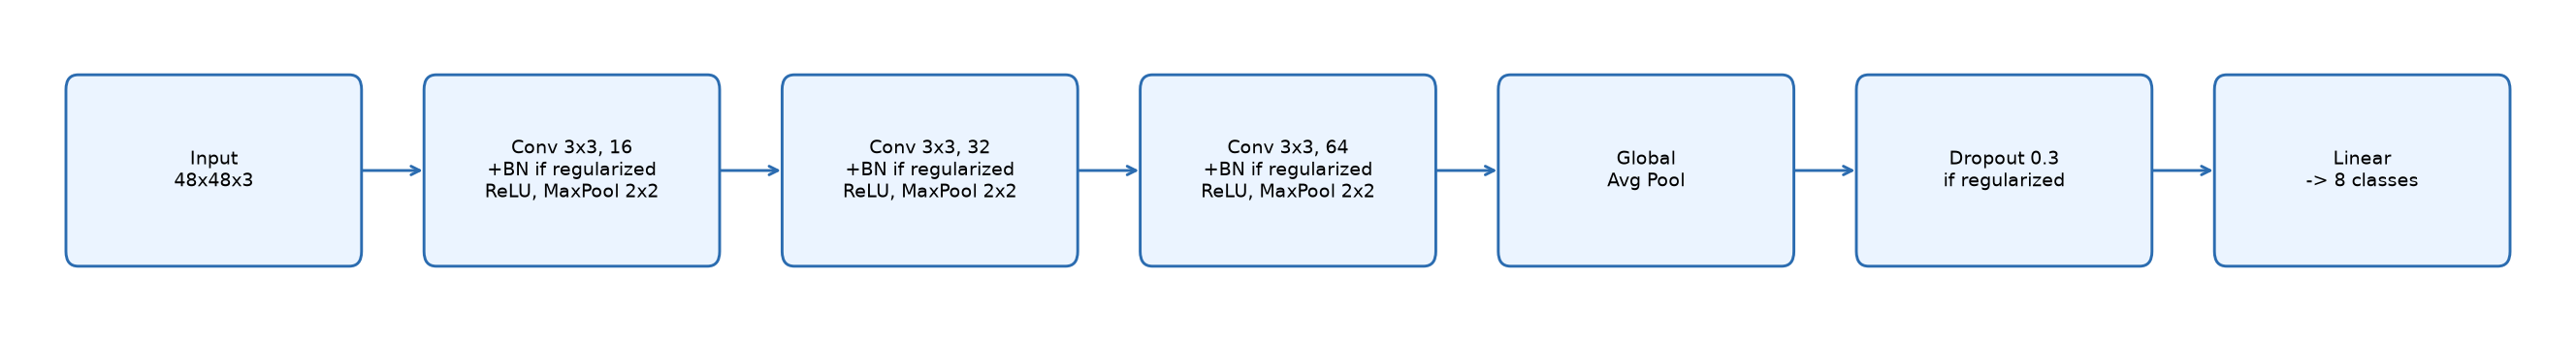

### Training setup and hyperparameters

Both variants were trained for 3 epochs using cross entropy loss, Adam with learning rate 0.001, and batch size 64. The checkpoint with the highest validation accuracy for each variant was saved; the variant with the higher validation accuracy was selected. Ties favor the baseline. Training ran on cpu. No test labels were used for optimization. These starting hyperparameters were then tuned by a grid search over learning rate and dropout rate, reported and justified in the Discussion section.

## Results

### Performance metrics

Baseline best validation accuracy: 54.686%

Regularized best validation accuracy: 75.556%

Selected model: regularized. Test accuracy: 74.589%; macro precision: 0.737; macro recall: 0.727; macro F1: 0.712; test cross entropy: 0.732.

| Class | Precision | Recall | F1-score | Support |
|---|---|---|---|---|
| airplane | 0.759 | 0.807 | 0.782 | 109 |
| car | 0.831 | 0.745 | 0.785 | 145 |
| cat | 0.608 | 0.466 | 0.528 | 133 |
| dog | 0.500 | 0.171 | 0.255 | 105 |
| flower | 0.959 | 0.732 | 0.830 | 127 |
| fruit | 0.872 | 1.000 | 0.932 | 150 |
| motorbike | 0.768 | 0.924 | 0.838 | 118 |
| person | 0.600 | 0.973 | 0.742 | 148 |

### Confusion matrix and classification report

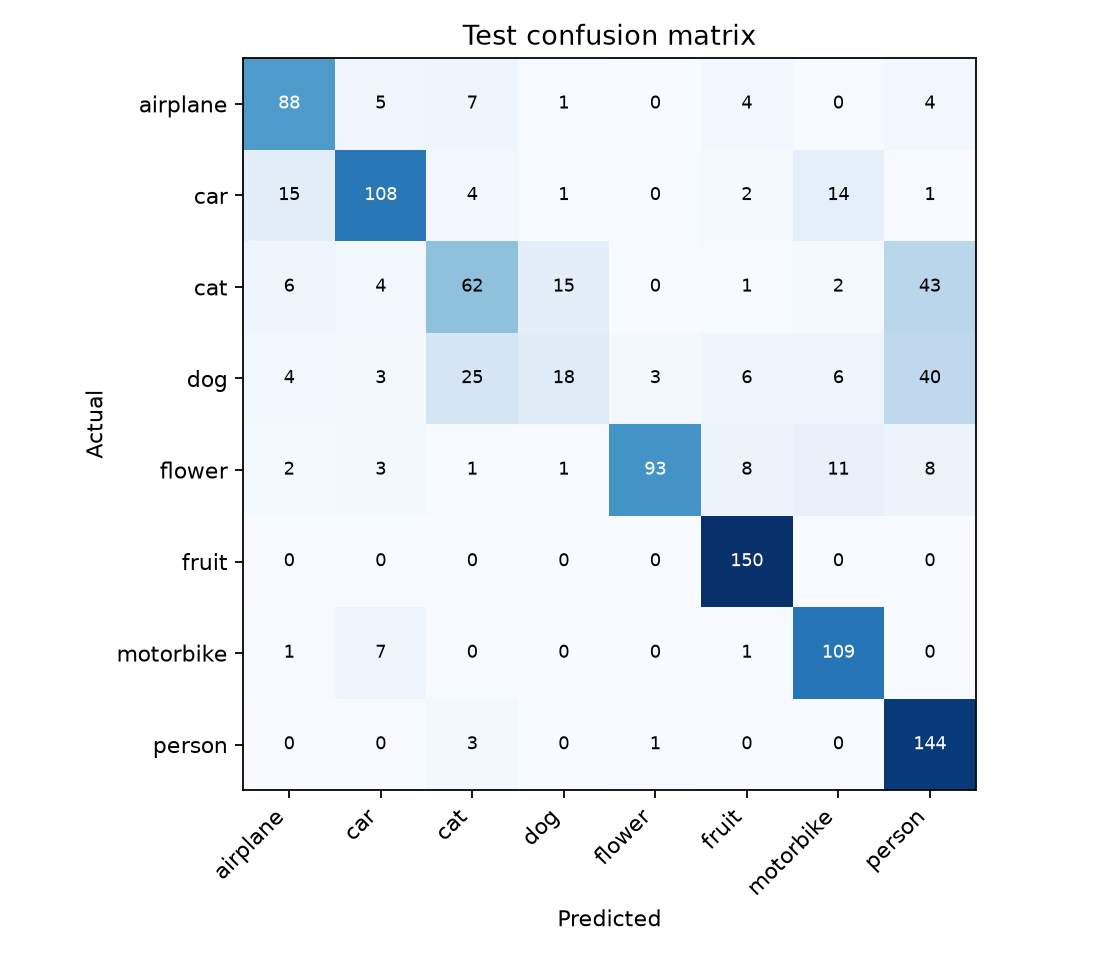

Figure. Confusion matrix for the selected model on the held-out test set.

### Training/validation loss and accuracy curves

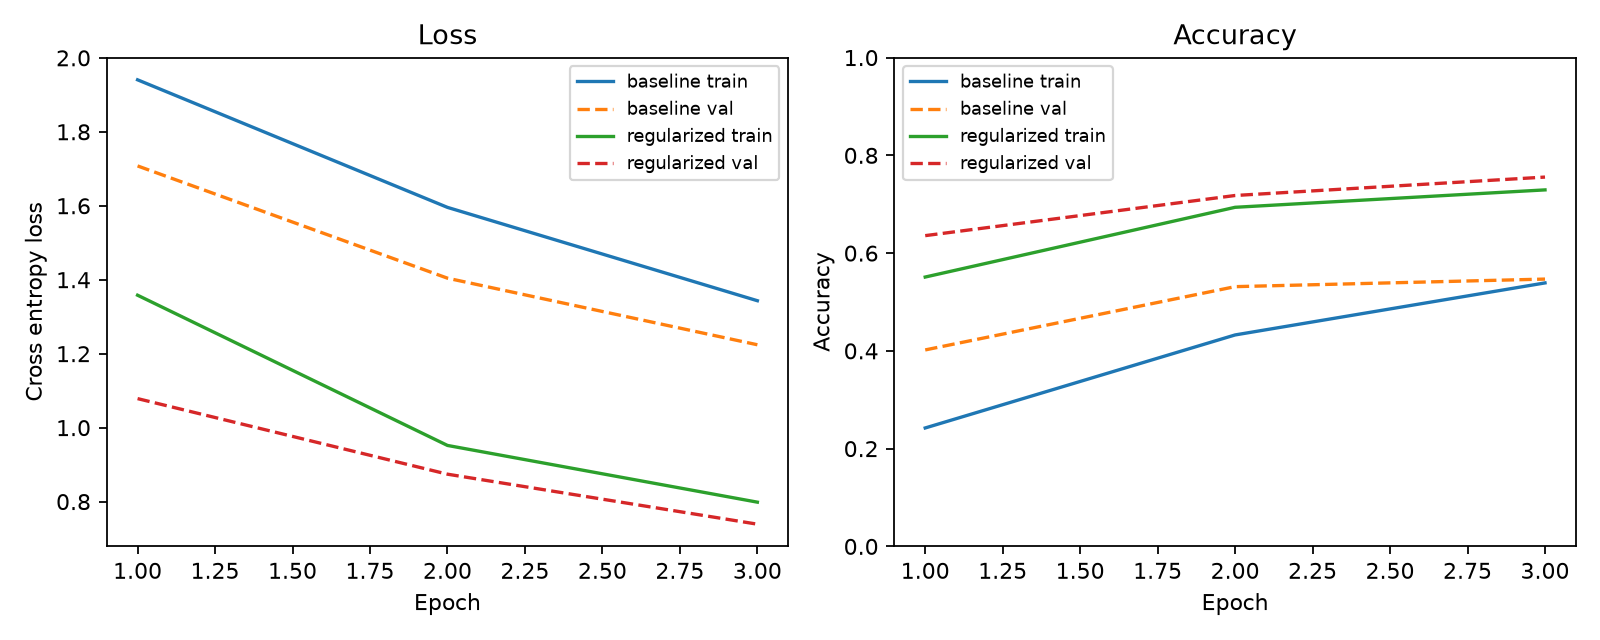

Figure. Training and validation loss and accuracy for both CNN variants.

## Discussion

### Observations, challenges, and insights

On the test set, recall was highest for fruit (1.000) and lowest for dog (0.171). Per the confusion matrix, the largest confusion errors on the test set were 43 true 'cat' images predicted as 'person'; 40 true 'dog' images predicted as 'person'; 25 true 'dog' images predicted as 'cat'. This shows that aggregate accuracy alone does not describe performance across all categories, and that per-class recall is a more informative diagnostic than a single accuracy number.

Training used a CPU, so images were resized to 48x48 and the CNN was limited to three convolution blocks. With 3 epochs per run, neither learning curve proves convergence. The baseline's lower training and validation accuracy suggests that optimization and model capacity, as well as regularization, could affect the observed gap. The repeated learning-rate/dropout setting produced different validation scores in the two search stages; this illustrates uncertainty from short stochastic runs, but two observations are insufficient to estimate run-to-run variance reliably.

### Justification for design and optimization decisions

The combined batch-normalization and 30%-dropout architecture was selected over the baseline because it reached 75.556% best validation accuracy versus 54.686% for the baseline under identical data, epochs, and optimizer settings. Batch normalization normalizes minibatch activations; dropout randomly removes classifier inputs during training. Because both were introduced together, these experiments do not isolate either component's individual contribution. Global average pooling limits classifier parameters compared with flattening a full feature map, which suits the small training set and CPU budget.

Starting from the winning architecture, learning rate and dropout were tuned by a two-stage grid search, each run for 3 epochs and scored by validation accuracy. First, the learning rate was swept with dropout fixed at its original value; then dropout was swept at the best learning rate found. This keeps the search small (six training runs, including one repeated configuration) while probing both an optimization and a regularization hyperparameter.

| Learning rate | Best val accuracy |
|---|---|
| 0.0003 | 69.469% |
| 0.001 | 75.556% |
| 0.003 | 68.986% |

| Dropout rate | Best val accuracy |
|---|---|
| 0.1 | 72.174% |
| 0.3 | 74.300% |
| 0.5 | 72.560% |

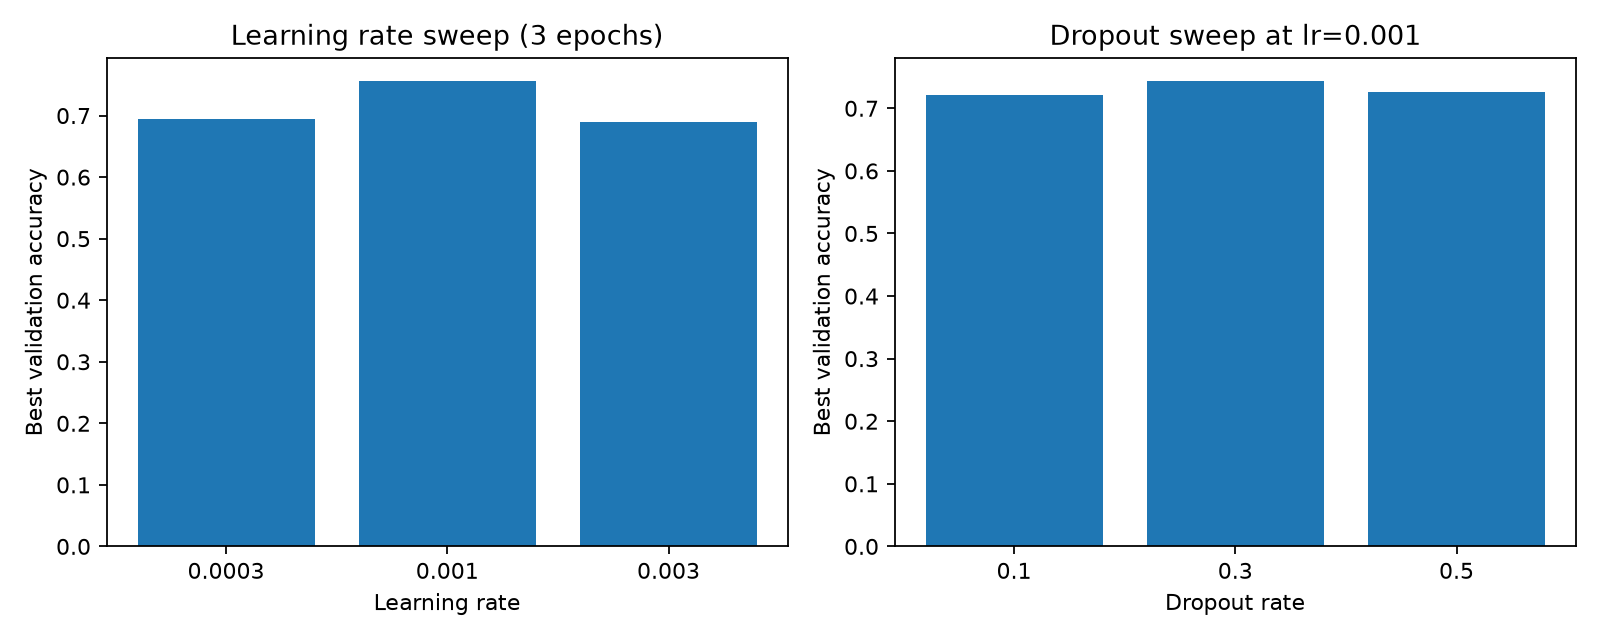

The best dropout-sweep run reached 74.300% validation accuracy, which did not exceed the original 75.556% achieved with learning rate 0.001 and dropout 0.3. The learning-rate sweep matched the original score at the same settings; the repeated dropout-sweep run scored lower. The original regularized model was therefore kept as the final model, and its test results above are unchanged.

### Potential improvements and future work

Future work could compare larger input sizes, more training epochs with early stopping, class-weighted loss to offset the uneven class counts, additional augmentation such as rotation and cropping, and pretrained feature extractors (transfer learning) rather than a network trained from scratch. Any of these changes would need a new validation comparison and a fresh held-out test set for a fair final estimate. Averaging several random seeds per hyperparameter configuration would also make the tuning comparison more reliable; the repeated three-epoch configuration produced different validation scores.

## Final Insight and Recommendations

The largest measured change in this comparison came from the combined architecture modification: adding batch normalization and dropout raised best validation accuracy by 20.9 percentage points (from 54.686% to 75.556%), a larger gain than any improvement retained after the learning-rate and dropout search. This comparison does not separate the effects of batch normalization and dropout.

...

Recommendation for deployment: the regularized model (test accuracy 74.589%, macro F1 0.712) is the strongest checkpoint measured in this project. These experiments do not establish deployment readiness. The low dog recall calls for targeted error analysis and evaluation on new images before any practical use.

### Reproducibility and source

Dataset: Prasun Roy, Natural Images, Kaggle, https://www.kaggle.com/datasets/prasunroy/natural-images. The submission notebook Image_Classification_CNN.ipynb contains data loading, both CNNs, training, evaluation, tuning, and visual analysis. Set DEFAULT_DATA to the directory containing the eight class folders, install requirements.txt, and run the notebook in order with 3 epochs per architecture. The stratified split and model initialization use seed 42; augmentation and CPU execution can still yield small differences across reruns. Metrics and figures used in this report are preserved in results/.

## Conclusion

A reproducible CNN pipeline was implemented for eight-class Natural Images classification. The regularized CNN was selected from a controlled architecture comparison and a follow-up hyperparameter search and achieved 74.589% accuracy and 0.712 macro F1 on 1035 held-out images. The saved metrics, curves, confusion matrix, and model checkpoints support reproduction and further tuning.

In [6]:
import json
from pathlib import Path
from IPython.display import display, Image as DisplayImage, Markdown

metrics = json.loads(Path("results/metrics.json").read_text())
test = metrics["test"]
tuning_path = Path("results/tuning.json")
tuning = json.loads(tuning_path.read_text()) if tuning_path.exists() else None
final, final_label = resolve_final(metrics, tuning)
display(Markdown(
    "| Class | Images |\n|---|---|\n" +
    "\n".join(f"| {name} | {count} |" for name, count in metrics["class_counts"].items())
))

display(Markdown("## Methodology"))
display(Markdown("### Preprocessing steps"))
display(Markdown(preprocessing(metrics)))
display(Markdown("### CNN architecture design"))
display(Markdown(architecture(metrics)))
architecture_diagram_path = Path("results/architecture_diagram.png")
draw_architecture_diagram(architecture_diagram_path, dropout=metrics.get("dropout", 0.3))
display(DisplayImage(filename=str(architecture_diagram_path)))
display(Markdown("### Training setup and hyperparameters"))
display(Markdown(training_setup(metrics)))

display(Markdown("## Results"))
display(Markdown("### Performance metrics"))
for line in results_summary_lines(metrics, test):
    display(Markdown(line))
header = "| Class | Precision | Recall | F1-score | Support |\n|---|---|---|---|---|"
rows = [
    f"| {name} | {test['classification_report'][name]['precision']:.3f} | "
    f"{test['classification_report'][name]['recall']:.3f} | "
    f"{test['classification_report'][name]['f1-score']:.3f} | "
    f"{int(test['classification_report'][name]['support'])} |"
    for name in metrics["class_counts"]
]
display(Markdown(header + "\n" + "\n".join(rows)))
display(Markdown("### Confusion matrix and classification report"))
display(DisplayImage(filename="results/confusion_matrix.png"))
display(Markdown("Figure. Confusion matrix for the selected model on the held-out test set."))
display(Markdown("### Training/validation loss and accuracy curves"))
display(DisplayImage(filename="results/training_curves.png"))
display(Markdown("Figure. Training and validation loss and accuracy for both CNN variants."))

display(Markdown("## Discussion"))
display(Markdown("### Observations, challenges, and insights"))
for paragraph in observations_paragraphs(metrics, final):
    display(Markdown(paragraph))

display(Markdown("### Justification for design and optimization decisions"))
display(Markdown(justification_intro(metrics)))
if tuning:
    display(Markdown(tuning_intro(tuning)))
    lr_rows = "\n".join(f"| {lr} | {tuning['learning_rate_sweep'][str(lr)]:.3%} |" for lr in tuning["learning_rates_tried"])
    display(Markdown("| Learning rate | Best val accuracy |\n|---|---|\n" + lr_rows))
    dropout_rows = "\n".join(f"| {d} | {tuning['dropout_sweep_at_best_lr'][str(d)]:.3%} |" for d in tuning["dropout_rates_tried"])
    display(Markdown("| Dropout rate | Best val accuracy |\n|---|---|\n" + dropout_rows))
    display(DisplayImage(filename="results/tuning_curves.png"))
    display(Markdown(tuning_outcome(metrics, tuning, final)))
    note = tuning_variance_note(tuning, metrics)
    if note:
        display(Markdown(note))

display(Markdown("### Potential improvements and future work"))
display(Markdown(future_work()))

display(Markdown("## Final Insight and Recommendations"))
for paragraph in final_insight_and_recommendations(metrics, tuning, final, final_label):
    display(Markdown(paragraph))

display(Markdown("### Reproducibility and source"))
display(Markdown(reproducibility(metrics)))

display(Markdown("## Conclusion"))
display(Markdown(conclusion(metrics, tuning, final, final_label)))
